# 🧠 CKP02 — DocMind RAG · Energia no Brasil

**FIAP · Prompt Engineering and Artificial Intelligence · 2º semestre · Checkpoint 02 (Módulo 2)**

| Integrante | RM |
|---|---|
| Daniel Mana | 571632 |
| Davi Queiroz Zuolo | 571669 |
| Gustavo Zagato | 569420 |
| Kayo Henderson | 570706 |

**Domínio:** Energia no Brasil — **geração distribuída, matriz energética, planejamento e recurso solar**.
Base com 6 documentos oficiais (ANEEL, EPE/MME e INPE), 839 páginas com texto extraível, que cobrem regulação, dados realizados,
projeções decenais e potencial solar. Isso permite perguntas não triviais que cruzam documentos diferentes.

**Objetivo:** pipeline RAG completo sobre uma base de conhecimento **real** do nosso domínio:
`load → split → embed → store → retrieve → generate`, com **comparação de chunking medida por RAGAS**
(faithfulness + answer_relevancy) e os diferenciais **metadata filtering**, **reranking** e **interface Gradio**.

### Mapa do notebook → rubrica
| Seção | O que entrega | Critério |
|---|---|---|
| 1–2 | Instalação, segredos e modelos (`nomic-embed-text` + `gemma4:cloud`, `temperature=0`) | Pipeline |
| 3 | Base de conhecimento real (≥5 documentos) com fontes e links | Base de conhecimento (2,0) |
| 4–5 | Split (Recursive, 3 tamanhos) → embed → ChromaDB local | Pipeline (3,5) |
| 6–7 | `buscar()` com filtro `where=` + reranking · `responder()` com citação | Pipeline + diferenciais |
| 8–9 | RAGAS por pergunta e por configuração · escolha justificada · análise de falha | Chunking + RAGAS (3,0) |
| 10–11 | Pipeline final (`buscar()` pronto para virar `@tool` no CKP03) · Gradio | Diferencial |
| 12 | Como adicionar novos documentos à base | Código e docs (1,5) |

### ⚙️ Pré-requisito para executar (importante)

Este notebook usa o **Ollama Cloud** para o modelo de chat `gemma4:cloud`, exigido pelo CKP02. Quem executar precisa de
uma chave própria — os *Secrets* do Colab são por usuário e não viajam com o notebook compartilhado.

1. Crie uma chave gratuita em <https://ollama.com> (*Settings → API keys*).
2. No Colab, ícone 🔑 **Secrets** → *Add new secret* → nome `OLLAMA_API_KEY`, cole a chave e **ative o acesso a este notebook**.
3. *Runtime → Run all*. O notebook clona a base do GitHub, sobe o Ollama local (embeddings) e roda tudo sozinho.

> Sem a chave, a execução para na Seção 2.2 com uma mensagem explicando exatamente o que falta — nenhuma outra célula depende
> de configuração manual. Tempo total num Colab CPU: ~8 minutos.

## 1. Instalação das dependências

> Se o Colab pedir *Restart session* depois da instalação, reinicie e rode *Run all* de novo (a segunda instalação é instantânea).

In [4]:
# Versões fixadas onde já houve incompatibilidade:
# o ragas 0.4.3 quebra com o langchain-community 0.4.2 (removeu um módulo que o ragas importa).
!pip install -q "ragas==0.4.3" "langchain-community==0.4.1" langchain-ollama langchain-text-splitters chromadb pymupdf datasets sentence-transformers gradio pandas matplotlib

## 2. Configuração do projeto

In [5]:
import os, re, json, time, math, shutil, zipfile, hashlib, subprocess, unicodedata, warnings
from pathlib import Path

import pandas as pd
import fitz  # PyMuPDF
import chromadb
from IPython.display import display, Markdown

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings, ChatOllama

warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_colwidth", 120)

# ===================== CONFIGURAÇÃO DO PROJETO =====================
# Nome do domínio (o mesmo da Aula 01). Também vira o nome da coleção no ChromaDB.
DOMINIO = "Energia no Brasil"

# Repositório público no GitHub com a pasta docs/ e o arquivo fontes.csv.
#    Assim o professor roda o "Run All" sem precisar enviar arquivo nenhum.
#    Deixe "" para enviar os arquivos manualmente pelo upload do Colab.
REPO_GIT = "https://github.com/DaviZuolo07/DocMind_RAG.git"

try:
    import google.colab  # noqa: F401  (só existe dentro do Colab)
    EM_COLAB = True
except ImportError:
    EM_COLAB = False
PASTA_PROJETO = Path("/content/docmind") if EM_COLAB else Path.cwd() / "docmind"
PASTA_DOCS    = PASTA_PROJETO / "docs"          # PDFs, TXT e MD da base
ARQ_FONTES    = PASTA_PROJETO / "fontes.csv"    # manifesto: título, tipo, categoria, data e link de cada documento
PASTA_CHROMA  = Path("/content/chroma_docmind") if EM_COLAB else Path.cwd() / "chroma_docmind"

# Modelos exigidos pelo CKP02 (não trocar)
OLLAMA_HOST      = "https://ollama.com"
MODELO_EMBEDDING = "nomic-embed-text"
MODELO_LLM       = "gemma4:cloud"

# Chunking: RecursiveCharacterTextSplitter com overlap de 12,5% (dentro da faixa 10–15% exigida)
CHUNK_SIZES       = [512, 1024]                 # configurações indexadas e comparadas com RAGAS (mínimo exigido: 2)
CHUNK_SIZES_ESTATISTICA = [256, 512, 1024]       # também medimos o 256 (só estatística) para justificar a escolha
TAMANHO_MINIMO_CHUNK = 60                        # descarta fragmentos sem conteúdo (números de página, rótulos soltos)
PROPORCAO_OVERLAP = 0.125
SEPARADORES       = ["\n\n", "\n", ". ", " ", ""]

# Recuperação
K_FINAL         = 6      # trechos enviados ao LLM (era 4; subimos após a análise de falha da Seção 9)
K_CANDIDATOS    = 12     # trechos buscados antes do reranking
MODELO_RERANKER = "cross-encoder/ms-marco-MiniLM-L-6-v2"

MSG_NAO_ENCONTRADO = "Não encontrei essa informação nos documentos fornecidos."
print(f"Domínio: {DOMINIO} | Colab: {EM_COLAB} | Pasta do projeto: {PASTA_PROJETO}")

Domínio: Energia no Brasil | Colab: True | Pasta do projeto: /content/docmind


In [6]:
def obter_segredo(nome: str) -> str:
    """Lê um segredo do Colab (Secrets) ou, fora do Colab, de uma variável de ambiente."""
    valor = None
    try:
        from google.colab import userdata
        valor = userdata.get(nome)
    except Exception:
        valor = os.environ.get(nome)
    if not valor:
        raise RuntimeError(f"Segredo '{nome}' não encontrado. Ícone 🔑 → Secrets → '{nome}' com acesso liberado.")
    return valor.strip()


import httpx

# LLM no Ollama Cloud (gemma4:cloud). A chave vai como Secret.
os.environ["OLLAMA_HOST"] = OLLAMA_HOST
os.environ["OLLAMA_API_KEY"] = obter_segredo("OLLAMA_API_KEY")
llm = ChatOllama(model=MODELO_LLM, temperature=0, base_url=OLLAMA_HOST)

# Embeddings: o Ollama Cloud recusa /api/embed (401) mesmo com chave válida.
# Então o MESMO nomic-embed-text roda num servidor Ollama local dentro do Colab.
EMB_HOST = "http://127.0.0.1:11434"
OLLAMA_VERSAO = ""                      # "" = versão mais recente; ex.: "0.35.1" para fixar
PREFIXO_OLLAMA = Path("/usr/local")     # o pacote traz bin/ollama e lib/ollama/ (onde fica o llama-server)
PACOTE_OLLAMA = "ollama-linux-amd64"


def localizar_llama_server() -> Path | None:
    """Procura o llama-server, o binário que carrega o modelo (separado do `ollama` desde a versão 0.30)."""
    pasta = PREFIXO_OLLAMA / "lib" / "ollama"
    return next(iter(sorted(pasta.rglob("llama-server"))), None) if pasta.exists() else None


def ollama_instalado_por_inteiro() -> bool:
    return (PREFIXO_OLLAMA / "bin" / "ollama").exists() and localizar_llama_server() is not None


def _rodar(comando: str, oque: str) -> None:
    """Executa um comando de shell e, se falhar, mostra o erro em vez de escondê-lo."""
    r = subprocess.run(["bash", "-c", f"set -o pipefail; {comando}"], capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"{oque} falhou (código {r.returncode}):\n{(r.stderr or r.stdout)[-1200:]}")


def _url_existe(url: str) -> bool:
    return subprocess.run(["curl", "--fail", "--silent", "--head", "--location", "--max-time", "30", url],
                          capture_output=True).returncode == 0


def fontes_do_pacote() -> list[tuple[str, str]]:
    """URLs candidatas, na ordem de tentativa: site oficial e, de reserva, o release no GitHub.
    As versões atuais usam .tar.zst; o .tgz só existe em versões antigas."""
    versao = OLLAMA_VERSAO.lstrip("v")
    sufixo = f"?version={versao}" if versao else ""
    github = (f"https://github.com/ollama/ollama/releases/download/v{versao}" if versao
              else "https://github.com/ollama/ollama/releases/latest/download")
    return [(f"{base}/{PACOTE_OLLAMA}{ext}{suf}", ext)
            for base, suf in (("https://ollama.com/download", sufixo), (github, ""))
            for ext in (".tar.zst", ".tgz")]


def instalar_ollama() -> None:
    """Baixa o pacote oficial do Ollama, extrai em /usr/local e confere se veio completo."""
    print("📦 Instalando o Ollama local (pacote de ~1,4 GB, 1–3 min)…")
    subprocess.run(["pkill", "-f", "ollama serve"])                     # derruba um servidor de instalação anterior
    time.sleep(1)
    shutil.rmtree(PREFIXO_OLLAMA / "lib" / "ollama", ignore_errors=True)
    (PREFIXO_OLLAMA / "bin" / "ollama").unlink(missing_ok=True)
    if shutil.which("zstd") is None:                                    # necessário para extrair o .tar.zst
        _rodar("apt-get -qq update && apt-get -qq install -y zstd", "Instalação do zstd")

    erros = []
    for url, ext in fontes_do_pacote():
        if not _url_existe(url):
            erros.append(f"não encontrado: {url}")
            continue
        arquivo = Path(f"/tmp/{PACOTE_OLLAMA}{ext}")
        try:
            # Baixa para um arquivo antes de extrair: um download interrompido falha aqui,
            # em vez de deixar uma instalação pela metade (binário sem llama-server).
            _rodar(f"curl --fail --location --silent --show-error --retry 3 --retry-delay 3 -o '{arquivo}' '{url}'",
                   "Download do Ollama")
            extrair = (f"zstd -d -c '{arquivo}' | tar -xf - -C '{PREFIXO_OLLAMA}'" if ext == ".tar.zst"
                       else f"tar -xzf '{arquivo}' -C '{PREFIXO_OLLAMA}'")
            _rodar(extrair, "Extração do Ollama")
        except RuntimeError as erro:
            erros.append(str(erro))
            continue
        finally:
            arquivo.unlink(missing_ok=True)
        if ollama_instalado_por_inteiro():
            saida = subprocess.run([str(PREFIXO_OLLAMA / "bin" / "ollama"), "--version"],
                                   capture_output=True, text=True).stdout
            versao = (re.findall(r"\d+\.\d+\.\d+", saida) or ["?"])[-1]
            print(f"✅ Ollama {versao} instalado · llama-server em {localizar_llama_server()}")
            return
        erros.append(f"pacote de {url} veio sem o llama-server")
    raise RuntimeError("Não foi possível instalar o Ollama local:\n- " + "\n- ".join(erros))


def ollama_local_no_ar() -> bool:
    try:
        return httpx.get(EMB_HOST, timeout=2).status_code == 200
    except Exception:
        return False


def iniciar_ollama_local() -> None:
    """Garante o Ollama instalado por inteiro, o servidor local no ar e o nomic-embed-text baixado."""
    env_local = {**os.environ, "OLLAMA_HOST": "127.0.0.1:11434"}
    env_local.pop("OLLAMA_API_KEY", None)        # o servidor local não usa a chave da nuvem
    binario = str(PREFIXO_OLLAMA / "bin" / "ollama")

    if not ollama_instalado_por_inteiro():       # ausente OU pela metade (binário sem llama-server)
        instalar_ollama()
    if not ollama_local_no_ar():
        subprocess.Popen([binario, "serve"], env=env_local, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for _ in range(60):
            if ollama_local_no_ar():
                break
            time.sleep(1)
        else:
            raise RuntimeError("O servidor Ollama local não respondeu em 60 s.")
    r = subprocess.run([binario, "pull", MODELO_EMBEDDING], env=env_local, capture_output=True, text=True)
    if r.returncode != 0:
        mensagem = re.sub(r"\x1b\[[0-9;?]*[A-Za-z]", "", r.stderr or r.stdout).strip()   # tira os códigos de cor do terminal
        raise RuntimeError(f"Falha ao baixar o {MODELO_EMBEDDING}:\n{mensagem[-800:]}")


iniciar_ollama_local()
embeddings = OllamaEmbeddings(model=MODELO_EMBEDDING, base_url=EMB_HOST)

# Teste rápido de conexão
vetor_teste = embeddings.embed_query("teste de conexão")
print(f"✅ Embedding OK — {MODELO_EMBEDDING} local, {len(vetor_teste)} dimensões")
print(f"✅ LLM OK — {MODELO_LLM}: {llm.invoke('Responda apenas: OK').content.strip()[:40]}")


📦 Instalando o Ollama local (pacote de ~1,4 GB, 1–3 min)…
✅ Ollama 0.35.1 instalado · llama-server em /usr/local/lib/ollama/llama-server
✅ Embedding OK — nomic-embed-text local, 768 dimensões
✅ LLM OK — gemma4:cloud: OK


In [7]:
def com_retentativas(funcao, *args, tentativas: int = 5, espera: float = 3.0, **kwargs):
    """Executa uma chamada ao Ollama Cloud com novas tentativas (protege contra limite de taxa e falhas de rede)."""
    for tentativa in range(1, tentativas + 1):
        try:
            return funcao(*args, **kwargs)
        except Exception as erro:
            if tentativa == tentativas:
                raise
            pausa = espera * 2 ** (tentativa - 1)
            print(f"   ⚠️ {type(erro).__name__}: {str(erro)[:80]} — nova tentativa em {pausa:.0f}s")
            time.sleep(pausa)


def slug(texto: str) -> str:
    """Converte um texto em identificador seguro (sem acento, espaço ou símbolo)."""
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    texto = re.sub(r"[^a-zA-Z0-9]+", "_", texto).strip("_").lower()
    return texto or "dominio"

## 3. Base de conhecimento (LOAD)

A base fica em `docs/` e cada arquivo é descrito no **manifesto `fontes.csv`**, que guarda a fonte oficial e os metadados usados
no *metadata filtering*:

| coluna | exemplo | uso |
|---|---|---|
| `arquivo` | `lei_14300_2022.pdf` | nome do arquivo dentro de `docs/` |
| `titulo` | `Lei nº 14.300/2022` | aparece na citação da resposta |
| `tipo` | `lei`, `manual`, `artigo`, `norma`, `faq` | filtro `where=` |
| `categoria` | assunto dentro do domínio | filtro `where=` |
| `data` | `2022-01-06` | data de publicação/versão |
| `url_fonte` | `https://...` | link de origem (obrigatório no CKP02) |

> 📌 Regras do CKP02: **≥5 documentos reais** do domínio, com fonte citada. Nada fictício nem Wikipedia genérica.
> PDFs precisam ter **texto selecionável** (PDF escaneado não tem texto para extrair).

**Curadoria da base:** ficaram fora a versão em inglês da Síntese do BEN (duplicata, misturaria idiomas na busca),
o BEN completo (273 páginas quase só de tabelas, redundante com a Síntese) e a planilha da matriz (formato tabular,
não textual). A Lei nº 14.300/2022 é coberta pela REN ANEEL nº 1.059/2023, que a regulamenta e traz as mesmas
definições (limites de micro e minigeração, créditos, PERS).

In [8]:
COLUNAS_FONTES = ["arquivo", "titulo", "tipo", "categoria", "data", "url_fonte"]
EXTENSOES_ACEITAS = {".pdf", ".txt", ".md"}


def preparar_pasta_documentos() -> None:
    """Garante que docs/ e fontes.csv existam: clona o repositório do grupo ou pede upload no Colab."""
    if REPO_GIT and not (PASTA_PROJETO / ".git").exists():
        shutil.rmtree(PASTA_PROJETO, ignore_errors=True)
        subprocess.run(["git", "clone", "--depth", "1", REPO_GIT, str(PASTA_PROJETO)], check=True)
    PASTA_DOCS.mkdir(parents=True, exist_ok=True)

    tem_documentos = any(p.suffix.lower() in EXTENSOES_ACEITAS for p in PASTA_DOCS.iterdir())
    if not tem_documentos and EM_COLAB:
        from google.colab import files
        print("📤 Envie os documentos (PDF/TXT/MD) e o fontes.csv — ou um .zip com tudo:")
        for nome, conteudo in files.upload().items():
            if nome.lower().endswith(".zip"):
                destino_zip = PASTA_PROJETO / nome
                destino_zip.write_bytes(conteudo)
                with zipfile.ZipFile(destino_zip) as z:
                    for membro in z.namelist():
                        nome_base = Path(membro).name
                        if not nome_base:
                            continue
                        destino = ARQ_FONTES if nome_base == "fontes.csv" else PASTA_DOCS / nome_base
                        destino.write_bytes(z.read(membro))
            elif nome == "fontes.csv":
                ARQ_FONTES.write_bytes(conteudo)
            else:
                (PASTA_DOCS / nome).write_bytes(conteudo)


def carregar_manifesto() -> pd.DataFrame:
    """Lê o fontes.csv e valida se cada documento existe e tem link de origem."""
    if not ARQ_FONTES.exists():
        # Cria um manifesto inicial com os arquivos encontrados, para o grupo completar
        arquivos = sorted(p.name for p in PASTA_DOCS.iterdir() if p.suffix.lower() in EXTENSOES_ACEITAS)
        pd.DataFrame({"arquivo": arquivos}).reindex(columns=COLUNAS_FONTES).to_csv(ARQ_FONTES, index=False)
        print(f"⚠️ fontes.csv não existia — criei um modelo em {ARQ_FONTES}. Preencha título, tipo, categoria, data e link.")

    manifesto = pd.read_csv(ARQ_FONTES, dtype=str).fillna("")
    faltando = [c for c in COLUNAS_FONTES if c not in manifesto.columns]
    if faltando:
        raise ValueError(f"fontes.csv sem as colunas: {faltando}")
    manifesto = manifesto[COLUNAS_FONTES].apply(lambda col: col.str.strip())

    inexistentes = [a for a in manifesto["arquivo"] if not (PASTA_DOCS / a).exists()]
    if inexistentes:
        raise FileNotFoundError(f"Arquivos listados no fontes.csv mas ausentes em docs/: {inexistentes}")
    fora_do_manifesto = sorted(
        p.name for p in PASTA_DOCS.iterdir()
        if p.suffix.lower() in EXTENSOES_ACEITAS and p.name not in set(manifesto["arquivo"])
    )
    if fora_do_manifesto:
        print(f"⚠️ Arquivos em docs/ fora do fontes.csv (serão ignorados): {fora_do_manifesto}")
    sem_link = manifesto.loc[manifesto["url_fonte"] == "", "arquivo"].tolist()
    if sem_link:
        print(f"⚠️ Documentos sem link de origem (o CKP02 exige fonte citada): {sem_link}")
    if len(manifesto) < 5:
        print(f"⚠️ A base tem {len(manifesto)} documento(s). O CKP02 exige no mínimo 5.")
    return manifesto


preparar_pasta_documentos()
manifesto = carregar_manifesto()

# Tabela de fontes com links (exigência: links de origem no notebook)
linhas = ["| # | Documento | Tipo | Categoria | Data | Fonte |", "|---|---|---|---|---|---|"]
for i, d in enumerate(manifesto.itertuples(), 1):
    link = f"[link]({d.url_fonte})" if d.url_fonte else "—"
    linhas.append(f"| {i} | {d.titulo or d.arquivo} | {d.tipo} | {d.categoria} | {d.data} | {link} |")
display(Markdown("\n".join(linhas)))

| # | Documento | Tipo | Categoria | Data | Fonte |
|---|---|---|---|---|---|
| 1 | Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) | resolucao | regulacao | 2023-02-07 | [link](http://www2.aneel.gov.br/cedoc/ren20231059.pdf) |
| 2 | Balanço Energético Nacional 2026 — Relatório Síntese (ano base 2025) | relatorio | matriz_energetica | 2026 | [link](https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/balanco-energetico-nacional-ben) |
| 3 | Plano Decenal de Expansão de Energia 2034 (MME/EPE) | plano | planejamento | 2024 | [link](https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034) |
| 4 | PDE 2034 — Caderno de Demanda de Eletricidade (EPE) | estudo | demanda | 2024 | [link](https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034) |
| 5 | PDE 2034 — Caderno de Demanda Energética do Setor de Transportes (EPE) | estudo | demanda | 2024-09-03 | [link](https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034) |
| 6 | Atlas Brasileiro de Energia Solar — 2ª edição (INPE/LABREN) | atlas | recurso_solar | 2017 | [link](https://www.absolar.org.br/wp-content/uploads/2021/02/Atlas_Brasileiro_Energia_Solar_2a_Edicao.pdf) |

In [9]:
def limpar_texto(texto: str) -> str:
    """Normaliza o texto extraído do PDF sem destruir a estrutura de parágrafos."""
    texto = texto.replace("\x00", "")
    texto = re.sub(r"(\w)-\n([a-zà-ú])", r"\1\2", texto)   # junta palavras hifenizadas na quebra de linha
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r" ?\n ?", "\n", texto)
    texto = re.sub(r"\n{3,}", "\n\n", texto)
    return texto.strip()


def metadados_base(linha) -> dict:
    """Metadados do manifesto que acompanham cada página e cada chunk (o ChromaDB não aceita None)."""
    return {
        "fonte": linha.arquivo,
        "titulo": linha.titulo or linha.arquivo,
        "tipo": linha.tipo or "nao_informado",
        "categoria": linha.categoria or "nao_informado",
        "data": linha.data or "",
        "url_fonte": linha.url_fonte or "",
    }


def carregar_documento(linha) -> list[Document]:
    """LOAD de um documento: PDF com PyMuPDF (uma página = um Document) ou TXT/MD (arquivo inteiro)."""
    caminho = PASTA_DOCS / linha.arquivo
    meta = metadados_base(linha)
    paginas = []
    if caminho.suffix.lower() == ".pdf":
        with fitz.open(caminho) as pdf:
            for numero, pagina in enumerate(pdf, start=1):
                texto = limpar_texto(pagina.get_text())
                if len(texto) >= 30:   # descarta páginas vazias (capa em branco, imagem sem texto)
                    paginas.append(Document(page_content=texto, metadata={**meta, "pagina": numero}))
    else:
        texto = limpar_texto(caminho.read_text(encoding="utf-8", errors="ignore"))
        if texto:
            paginas.append(Document(page_content=texto, metadata={**meta, "pagina": 1}))
    return paginas


def carregar_base(manifesto: pd.DataFrame) -> list[Document]:
    """LOAD da base inteira, com um resumo por documento."""
    todas, resumo = [], []
    for linha in manifesto.itertuples():
        paginas = carregar_documento(linha)
        todas.extend(paginas)
        resumo.append({"documento": linha.titulo or linha.arquivo, "páginas com texto": len(paginas),
                       "caracteres": sum(len(p.page_content) for p in paginas)})
        if not paginas:
            print(f"⚠️ {linha.arquivo}: nenhum texto extraído (PDF escaneado?). Troque por uma versão com texto.")
    display(pd.DataFrame(resumo))
    return todas


paginas = carregar_base(manifesto)
print(f"\nTotal: {len(paginas)} páginas · {sum(len(p.page_content) for p in paginas):,} caracteres")
print(f"\nExemplo — {paginas[0].metadata['titulo']}, pág. {paginas[0].metadata['pagina']}:\n{paginas[0].page_content[:400]}")

,documento,páginas com texto,caracteres
0,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída),45,108886
1,Balanço Energético Nacional 2026 — Relatório Síntese (ano base 2025),73,68550
2,Plano Decenal de Expansão de Energia 2034 (MME/EPE),576,1378163
3,PDE 2034 — Caderno de Demanda de Eletricidade (EPE),18,14323
4,PDE 2034 — Caderno de Demanda Energética do Setor de Transportes (EPE),48,40546
5,Atlas Brasileiro de Energia Solar — 2ª edição (INPE/LABREN),79,215393



Total: 839 páginas · 1,825,861 caracteres

Exemplo — Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), pág. 1:
AGÊNCIA NACIONAL DE ENERGIA ELÉTRICA – ANEEL

RESOLUÇÃO NORMATIVA ANEEL Nº 1.059, DE 7 DE FEVEREIRO DE 2023

Aprimora as regras para a conexão e o faturamento
de centrais de microgeração e minigeração
distribuída em sistemas de distribuição de energia
elétrica, bem como as regras do Sistema de
Compensação de Energia Elétrica; altera as
Resoluções Normativas n° 920, de 23 de fevereiro de
2021, 956,


## 4. Chunking (SPLIT) — três configurações para comparar

Mesma estratégia (`RecursiveCharacterTextSplitter` com os separadores da Aula 06), variando só o `chunk_size`.
Assim a comparação isola **uma** variável. O overlap acompanha o tamanho (12,5%).

| config | chunk_size | chunk_overlap | hipótese |
|---|---|---|---|
| Recursive-512 | 512 | 64 | trecho específico: bom para respostas pontuais (limites, prazos, percentuais) |
| Recursive-1024 | 1024 | 128 | mais contexto: mantém regra + exceções no mesmo trecho, mas o embedding fica mais "diluído" |

Fragmentos com menos de 60 caracteres (números de página, rótulos de gráfico) são descartados: não têm conteúdo
recuperável e só poluem a busca.

> **Por que o 256 ficou só na estatística:** a tabela abaixo mostra que, nesta base de 839 páginas, ele gera quase o dobro
> de chunks do 512, com tamanho médio abaixo de 200 caracteres. Em PDFs de relatório isso vira pedaços de tabela e de
> legenda sem contexto. Indexá-lo dobraria as chamadas de embedding ao Ollama Cloud sem chance real de vencer.

In [10]:
def gerar_chunks(paginas: list[Document], chunk_size: int) -> list[Document]:
    """SPLIT: divide as páginas em chunks e cria um id estável para cada um."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=int(round(chunk_size * PROPORCAO_OVERLAP)),
        separators=SEPARADORES,
    )
    chunks = [c for c in splitter.split_documents(paginas) if len(c.page_content.strip()) >= TAMANHO_MINIMO_CHUNK]
    for i, chunk in enumerate(chunks):
        assinatura = f"{chunk.metadata['fonte']}|{chunk.metadata['pagina']}|{i}|{chunk.page_content}"
        chunk.metadata["chunk_id"] = f"cs{chunk_size}-{hashlib.md5(assinatura.encode()).hexdigest()[:12]}"
        chunk.metadata["chunk_size"] = chunk_size
    return chunks


chunks_por_config = {cs: gerar_chunks(paginas, cs) for cs in sorted(set(CHUNK_SIZES_ESTATISTICA) | set(CHUNK_SIZES))}

estatisticas = []
for cs, chunks in chunks_por_config.items():
    tamanhos = [len(c.page_content) for c in chunks]
    estatisticas.append({"config": f"Recursive-{cs}", "chunk_overlap": int(round(cs * PROPORCAO_OVERLAP)),
                         "nº de chunks": len(chunks), "tamanho médio": round(sum(tamanhos) / len(tamanhos)),
                         "mín": min(tamanhos), "máx": max(tamanhos),
                         "indexada e avaliada": "sim" if cs in CHUNK_SIZES else "não (ver nota)"})
display(pd.DataFrame(estatisticas))

,config,chunk_overlap,nº de chunks,tamanho médio,mín,máx,indexada e avaliada
0,Recursive-256,32,9583,191,60,256,não (ver nota)
1,Recursive-512,64,4836,384,60,512,sim
2,Recursive-1024,128,2792,690,61,1024,sim


## 5. EMBED + STORE — uma coleção ChromaDB por configuração

Os vetores são gerados no nosso código (`embed_documents`) e o ChromaDB só armazena e busca, como recomendado na Aula 05.
A coleção usa distância **cosseno** e tem o nome do domínio (`<dominio>_cs<tamanho>`).

In [11]:
# Antes de indexar milhares de chunks, confirma que o servidor local continua no ar e devolve vetores de 768 dimensões.
iniciar_ollama_local()
for tentativa in range(1, 6):
    try:
        assert len(embeddings.embed_query("validação final")) == 768
        print(f"✅ Ollama local ativo e '{MODELO_EMBEDDING}' pronto para uso.")
        break
    except Exception as erro:
        print(f"⚠️ Tentativa {tentativa}/5 falhou ({type(erro).__name__}: {str(erro)[:120]}). Nova tentativa em 5 s…")
        time.sleep(5)
else:
    raise RuntimeError("O Ollama local não respondeu ao teste de embedding. Veja o erro acima.")


✅ Ollama local ativo e 'nomic-embed-text' pronto para uso.


In [12]:
cliente_chroma = chromadb.PersistentClient(path=str(PASTA_CHROMA))


def nome_colecao(chunk_size: int) -> str:
    """Nome da coleção: domínio + tamanho do chunk (ex.: recarga_veiculos_eletricos_cs512)."""
    return f"{slug(DOMINIO)[:50]}_cs{chunk_size}"


def adicionar_chunks(colecao, chunks: list[Document], lote: int = 64) -> None:
    """EMBED + STORE: gera os embeddings em lotes e grava texto, vetor, id e metadados no ChromaDB."""
    for inicio in range(0, len(chunks), lote):
        if inicio and inicio % (lote * 25) == 0:
            print(f"   … {inicio}/{len(chunks)} chunks", flush=True)
        bloco = chunks[inicio:inicio + lote]
        vetores = com_retentativas(embeddings.embed_documents, [c.page_content for c in bloco])
        colecao.add(
            ids=[c.metadata["chunk_id"] for c in bloco],
            documents=[c.page_content for c in bloco],
            embeddings=vetores,
            metadatas=[c.metadata for c in bloco],
        )


def assinatura_base(chunks: list[Document], chunk_size: int) -> str:
    """Impressão digital da base + parâmetros: se nada mudou, a coleção já indexada é reaproveitada."""
    conteudo = "|".join([manifesto.to_csv(index=False), str(chunk_size), str(PROPORCAO_OVERLAP),
                         str(SEPARADORES), MODELO_EMBEDDING, str(len(chunks))])
    return hashlib.md5(conteudo.encode()).hexdigest()


def indexar(chunks: list[Document], chunk_size: int, forcar: bool = False):
    """Cria a coleção da configuração e indexa os chunks (reaproveita se a base não mudou)."""
    nome = nome_colecao(chunk_size)
    assinatura = assinatura_base(chunks, chunk_size)
    if nome in [c.name for c in cliente_chroma.list_collections()]:
        existente = cliente_chroma.get_collection(nome)
        if not forcar and (existente.metadata or {}).get("assinatura") == assinatura and existente.count() == len(chunks):
            print(f"♻️ {nome}: base não mudou, reaproveitando {existente.count()} chunks já indexados")
            return existente
        cliente_chroma.delete_collection(nome)
    colecao = cliente_chroma.create_collection(
        name=nome,
        metadata={"hnsw:space": "cosine", "dominio": DOMINIO, "chunk_size": chunk_size, "assinatura": assinatura},
    )
    adicionar_chunks(colecao, chunks)
    return colecao


# Garante que o Ollama local está ativo antes de começar
iniciar_ollama_local()

colecoes = {}
for cs in CHUNK_SIZES:
    chunks = chunks_por_config[cs]
    inicio = time.time()
    colecoes[cs] = indexar(chunks, cs)
    print(f"✅ {nome_colecao(cs)}: {colecoes[cs].count()} chunks prontos em {time.time() - inicio:.0f}s")

# Coleção usada por padrão até a avaliação escolher a vencedora (Seção 8)
COLECAO_ATIVA = colecoes[512] if 512 in colecoes else colecoes[CHUNK_SIZES[0]]

   … 1600/4836 chunks
   … 3200/4836 chunks
   … 4800/4836 chunks
✅ energia_no_brasil_cs512: 4836 chunks prontos em 90s
   … 1600/2792 chunks
✅ energia_no_brasil_cs1024: 2792 chunks prontos em 47s


## 6. RETRIEVE — `buscar()` com metadata filtering e reranking

`buscar(consulta)` é a peça que vira `@tool` no CKP03. Ela:
1. gera o embedding da pergunta (`embed_query`);
2. consulta o ChromaDB, opcionalmente com filtro de metadados (`where=`), buscando `K_CANDIDATOS` trechos;
3. reordena os candidatos com o **cross-encoder** `ms-marco-MiniLM-L-6-v2` e devolve os `K_FINAL` melhores.

> 💡 O cross-encoder lê pergunta e trecho **juntos** e dá uma nota de relevância. É mais lento que a busca vetorial,
> por isso só roda sobre os poucos candidatos já pré-selecionados.

In [13]:
_reranker = None
_aviso_reranker = False


def obter_reranker():
    """Carrega o cross-encoder só na primeira vez que for usado."""
    global _reranker
    if _reranker is None:
        from sentence_transformers import CrossEncoder
        _reranker = CrossEncoder(MODELO_RERANKER)
    return _reranker


def buscar(consulta: str, k: int = K_FINAL, filtro: dict | None = None,
           rerank: bool = True, colecao=None) -> list[dict]:
    """Busca semântica na base do domínio.

    Parâmetros:
        consulta: pergunta em linguagem natural.
        k: quantidade de trechos devolvidos.
        filtro: filtro de metadados do ChromaDB, ex.: {"categoria": "seguranca"} ou
                {"$and": [{"tipo": "lei"}, {"categoria": "tarifas"}]}.
        rerank: se True, reordena os candidatos com o cross-encoder.
        colecao: coleção do ChromaDB (padrão: COLECAO_ATIVA).
    Retorna: lista de dicts com texto, metadados da fonte e scores.
    """
    global _aviso_reranker
    colecao = colecao or COLECAO_ATIVA
    n_buscar = min(K_CANDIDATOS if rerank else k, colecao.count())
    vetor = com_retentativas(embeddings.embed_query, consulta)
    resultado = colecao.query(
        query_embeddings=[vetor], n_results=n_buscar, where=filtro or None,
        include=["documents", "metadatas", "distances"],
    )
    trechos = [
        {"texto": texto, **meta, "similaridade": round(1 - distancia, 4)}   # cosseno: similaridade = 1 − distância
        for texto, meta, distancia in zip(resultado["documents"][0], resultado["metadatas"][0], resultado["distances"][0])
    ]
    if rerank and trechos:
        try:
            notas = obter_reranker().predict([(consulta, t["texto"]) for t in trechos])
            for trecho, nota in zip(trechos, notas):
                trecho["score_rerank"] = round(float(nota), 4)
            trechos.sort(key=lambda t: t["score_rerank"], reverse=True)
        except Exception as erro:
            if not _aviso_reranker:
                print(f"⚠️ Reranking indisponível ({type(erro).__name__}); seguindo só com a busca vetorial.")
                _aviso_reranker = True
    return trechos[:k]


def mostrar_trechos(trechos: list[dict], tamanho: int = 220) -> None:
    """Exibe os trechos recuperados em formato de tabela."""
    display(pd.DataFrame([{
        "fonte": f"{t['titulo']} · p.{t['pagina']}", "categoria": t["categoria"],
        "similaridade": t["similaridade"], "rerank": t.get("score_rerank", "—"),
        "trecho": t["texto"][:tamanho].replace("\n", " ") + "…",
    } for t in trechos]))

In [14]:
consulta_exemplo = "Por quanto tempo valem os créditos de energia injetada na rede?"

print("🔎 Busca vetorial pura (sem reranking):")
mostrar_trechos(buscar(consulta_exemplo, rerank=False))
print("🔎 Com reranking por cross-encoder:")
mostrar_trechos(buscar(consulta_exemplo, rerank=True))

🔎 Busca vetorial pura (sem reranking):


,fonte,categoria,similaridade,rerank,trecho
0,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.21,regulacao,0.8162,—,"I - na mesma unidade consumidora que injetou a energia, para ser utilizado em ciclos de faturamento subsequentes, tr..."
1,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.40,regulacao,0.7847,—,"a) o total de energia injetada, excedentes de energia e créditos de energia utilizados no ciclo de faturamento corre..."
2,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.33,regulacao,0.7696,—,152-A - Energia compensada: energia elétrica ativa consumida da rede e compensada pela energia elétrica ativa injeta...
3,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.25,regulacao,0.7640,—,"§ 1º Ao final do prazo de validade estabelecido no caput, os créditos de energia devem ser revertidos para a modicid..."
4,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.3,regulacao,0.7633,—,"ativa é injetada por unidade consumidora com microgeração ou minigeração distribuída na rede da distribuidora local,..."
5,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.26,regulacao,0.7578,—,"§ 3º Caso não haja outras unidades consumidoras do titular atendidas pela mesma distribuidora, os créditos de energi..."


🔎 Com reranking por cross-encoder:


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

,fonte,categoria,similaridade,rerank,trecho
0,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.3,regulacao,0.7633,4.3113,"ativa é injetada por unidade consumidora com microgeração ou minigeração distribuída na rede da distribuidora local,..."
1,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.40,regulacao,0.7847,4.2550,"a) o total de energia injetada, excedentes de energia e créditos de energia utilizados no ciclo de faturamento corre..."
2,Atlas Brasileiro de Energia Solar — 2ª edição (INPE/LABREN) · p.61,recurso_solar,0.7574,4.1162,pela REN 482/2012 era de 1000 kWp em 2012 e em 2016 este limite foi ampliado pela REN 687/2015 para até 5000 kWp po...
3,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.33,regulacao,0.7696,3.7037,152-A - Energia compensada: energia elétrica ativa consumida da rede e compensada pela energia elétrica ativa injeta...
4,Atlas Brasileiro de Energia Solar — 2ª edição (INPE/LABREN) · p.61,recurso_solar,0.7543,2.3759,"minigeração. Através da Resolução Normativa 482/2012, o Brasil adotou o mecanismo de compensação de energia, ..."
5,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.25,regulacao,0.7640,2.2180,"§ 1º Ao final do prazo de validade estabelecido no caput, os créditos de energia devem ser revertidos para a modicid..."


### Metadata filtering (`where=`)
O mesmo `buscar()` restringe a busca a um subconjunto da base **antes** do cálculo de similaridade.

In [15]:
categoria_exemplo = manifesto["categoria"].replace("", "nao_informado").iloc[0]
tipo_exemplo = manifesto["tipo"].replace("", "nao_informado").iloc[0]

print(f"🔎 Filtro simples: categoria = '{categoria_exemplo}'")
trechos_filtrados = buscar(consulta_exemplo, filtro={"categoria": categoria_exemplo})
mostrar_trechos(trechos_filtrados)
assert all(t["categoria"] == categoria_exemplo for t in trechos_filtrados), "Filtro de metadados falhou"

print(f"🔎 Filtro composto: tipo = '{tipo_exemplo}' E categoria = '{categoria_exemplo}'")
mostrar_trechos(buscar(consulta_exemplo, filtro={"$and": [{"tipo": tipo_exemplo}, {"categoria": categoria_exemplo}]}))

🔎 Filtro simples: categoria = 'regulacao'


,fonte,categoria,similaridade,rerank,trecho
0,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.3,regulacao,0.7633,4.3113,"ativa é injetada por unidade consumidora com microgeração ou minigeração distribuída na rede da distribuidora local,..."
1,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.40,regulacao,0.7847,4.2550,"a) o total de energia injetada, excedentes de energia e créditos de energia utilizados no ciclo de faturamento corre..."
2,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.33,regulacao,0.7696,3.7037,152-A - Energia compensada: energia elétrica ativa consumida da rede e compensada pela energia elétrica ativa injeta...
3,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.22,regulacao,0.7503,2.8349,§ 5º Caso o excedente de energia ou o crédito de energia sejam utilizados em postos tarifários distintos da injeção ...
4,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.25,regulacao,0.7640,2.2180,"§ 1º Ao final do prazo de validade estabelecido no caput, os créditos de energia devem ser revertidos para a modicid..."
5,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.21,regulacao,0.8162,1.8202,"I - na mesma unidade consumidora que injetou a energia, para ser utilizado em ciclos de faturamento subsequentes, tr..."


🔎 Filtro composto: tipo = 'resolucao' E categoria = 'regulacao'


,fonte,categoria,similaridade,rerank,trecho
0,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.3,regulacao,0.7633,4.3113,"ativa é injetada por unidade consumidora com microgeração ou minigeração distribuída na rede da distribuidora local,..."
1,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.40,regulacao,0.7847,4.2550,"a) o total de energia injetada, excedentes de energia e créditos de energia utilizados no ciclo de faturamento corre..."
2,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.33,regulacao,0.7696,3.7037,152-A - Energia compensada: energia elétrica ativa consumida da rede e compensada pela energia elétrica ativa injeta...
3,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.22,regulacao,0.7503,2.8349,§ 5º Caso o excedente de energia ou o crédito de energia sejam utilizados em postos tarifários distintos da injeção ...
4,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.25,regulacao,0.7640,2.2180,"§ 1º Ao final do prazo de validade estabelecido no caput, os créditos de energia devem ser revertidos para a modicid..."
5,Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída) · p.21,regulacao,0.8162,1.8202,"I - na mesma unidade consumidora que injetou a energia, para ser utilizado em ciclos de faturamento subsequentes, tr..."


## 7. GENERATE — resposta fundamentada com citação da fonte

O prompt tem os três mecanismos de *grounding* da Aula 06: responder **só** com o contexto, **citar a fonte** e usar uma
resposta padrão quando a informação não está nos documentos.

In [16]:
INSTRUCOES_SISTEMA = """<persona>
Você é o DocMind, assistente especializado no domínio "{dominio}". Responde em português do Brasil
com base EXCLUSIVAMENTE nos trechos de documentos fornecidos.
</persona>

<instrucoes>
- Use SOMENTE informações presentes no <contexto>. Nunca use conhecimento externo, nunca invente nem extrapole.
- Toda afirmação deve trazer a citação do trecho de origem no formato (Fonte: <título>, p. <página>).
- Se o contexto não tiver a resposta, responda exatamente: "{nao_encontrado}"
- Se o contexto responder só parte da pergunta, responda essa parte e diga o que não foi encontrado.
- COMECE pela resposta direta à pergunta, numa única frase, com o número ou o termo exato do trecho.
  Só depois acrescente condições, exceções ou detalhes, se houver.
- Não acrescente contexto que a pergunta não pediu.
- Copie números, prazos e percentuais exatamente como aparecem no trecho; nunca arredonde nem converta.
- Seja direto: no máximo 2 parágrafos curtos ou uma lista curta.
</instrucoes>"""

prompt_rag = ChatPromptTemplate.from_messages([
    ("system", INSTRUCOES_SISTEMA),
    ("human", "<contexto>\n{contexto}\n</contexto>\n\n<pergunta>\n{pergunta}\n</pergunta>"),
]).partial(dominio=DOMINIO, nao_encontrado=MSG_NAO_ENCONTRADO)

cadeia_geracao = prompt_rag | llm | StrOutputParser()   # LCEL: prompt | llm | parser


def formatar_contexto(trechos: list[dict]) -> str:
    """Monta o contexto numerado, com título e página de cada trecho, para o LLM citar."""
    return "\n\n---\n\n".join(
        f"[Trecho {i} — {t['titulo']}, p. {t['pagina']}]\n{t['texto']}" for i, t in enumerate(trechos, 1)
    )


def remover_raciocinio(texto: str) -> str:
    """Remove blocos de raciocínio (<think>...</think>) caso o modelo os devolva no texto."""
    return re.sub(r"<think>.*?</think>", "", texto, flags=re.DOTALL).strip()


def formatar_fontes(trechos: list[dict]) -> str:
    """Lista as fontes únicas (documento + página + link) dos trechos usados."""
    vistas, linhas = set(), []
    for t in trechos:
        chave = (t["fonte"], t["pagina"])
        if chave not in vistas:
            vistas.add(chave)
            link = f" — {t['url_fonte']}" if t.get("url_fonte") else ""
            linhas.append(f"- {t['titulo']}, p. {t['pagina']}{link}")
    return "\n".join(linhas)


def responder(pergunta: str, k: int = K_FINAL, filtro: dict | None = None,
              rerank: bool = True, colecao=None) -> dict:
    """Pipeline de inferência completo: retrieve → generate. Devolve resposta + trechos de origem."""
    trechos = buscar(pergunta, k=k, filtro=filtro, rerank=rerank, colecao=colecao)
    if not trechos:
        return {"pergunta": pergunta, "resposta": MSG_NAO_ENCONTRADO, "trechos": []}
    resposta = com_retentativas(cadeia_geracao.invoke, {"contexto": formatar_contexto(trechos), "pergunta": pergunta})
    return {"pergunta": pergunta, "resposta": remover_raciocinio(resposta), "trechos": trechos}


# Versão Runnable (LCEL) do pipeline inteiro: pergunta (str) → resposta (str)
chain_rag = RunnableLambda(lambda pergunta: responder(pergunta)["resposta"])

In [17]:
# A última pergunta testa o grounding: está FORA da base, então o sistema deve dizer que não encontrou
PERGUNTAS_TESTE = [
    "Qual é a diferença entre microgeração e minigeração distribuída?",
    "Por que as baterias atrás do medidor ainda não são economicamente atrativas no Brasil?",
    "Qual é a capital da Austrália?",   # fora do domínio → deve responder que não encontrou
]

for pergunta in PERGUNTAS_TESTE:
    r = responder(pergunta)
    display(Markdown(f"**❓ {pergunta}**\n\n{r['resposta']}\n\n*Trechos usados:*\n{formatar_fontes(r['trechos'])}"))

**❓ Qual é a diferença entre microgeração e minigeração distribuída?**

Não encontrei essa informação nos documentos fornecidos.

*Trechos usados:*
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 15 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 35 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 26 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 21 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 40 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf

**❓ Por que as baterias atrás do medidor ainda não são economicamente atrativas no Brasil?**

O uso de baterias atrás-do-medidor no Brasil ainda é pouco utilizado em função do seu elevado custo e das poucas possibilidades de aplicação com retorno (Fonte: Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 380).

*Trechos usados:*
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 21 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 387 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 380 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 462 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 434 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034

**❓ Qual é a capital da Austrália?**

Não encontrei essa informação nos documentos fornecidos.

*Trechos usados:*
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 479 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 228 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 551 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 25 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 159 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 193 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034

## 8. Avaliação com RAGAS — qual chunking venceu?

- **faithfulness**: proporção das afirmações da resposta que são sustentadas pelos trechos recuperados (detecta alucinação).
- **answer_relevancy**: o quanto a resposta realmente responde à pergunta.
- Metas do CKP02: faithfulness **≥ 0,7** (aprovação) e **≥ 0,9** (zona ideal). Abaixo de 0,5 = alucinação significativa.

**Desenho do experimento:** mesmas perguntas, mesmo prompt, mesmo `k` e **sem reranking**. A única coisa que muda entre
as configurações é o `chunk_size`. O juiz (LLM-as-judge) também é o `gemma4:cloud`, com `temperature=0`.

> As 8 perguntas cobrem **os 6 documentos** e têm a resposta conferida no PDF. Cada uma registra o documento onde a
> resposta está, o que permite medir também se o retriever trouxe a fonte certa (coluna `recuperou_fonte_esperada`).
> Perguntas fora da base não entram aqui (derrubam o answer_relevancy por definição); o grounding foi testado na Seção 7.

In [18]:
# Perguntas com resposta conferida nos PDFs + documento onde a resposta está (usado para medir a recuperação)
PERGUNTAS_AVALIACAO = [
    ("Qual é a potência máxima de uma central de microgeração distribuída?",
     "ren_aneel_1059_2023.pdf"),            # ≤ 75 kW
    ("Em quanto tempo expiram os créditos de energia do sistema de compensação?",
     "ren_aneel_1059_2023.pdf"),            # 60 meses
    ("O que é o Programa de Energia Renovável Social (PERS) e a quem ele se destina?",
     "ren_aneel_1059_2023.pdf"),            # FV para a Subclasse Residencial Baixa Renda
    ("Qual foi a participação das fontes renováveis na matriz elétrica brasileira em 2025?",
     "ben_sintese_2026.pdf"),               # 86,8%
    ("Qual capacidade instalada de micro e minigeração distribuída o PDE 2034 projeta para 2034 no cenário de referência?",
     "pde2034_plano_aprovado.pdf"),         # 58,8 GW, ~9% da carga
    ("Qual é o crescimento médio anual do consumo de eletricidade projetado até 2034?",
     "pde2034_caderno_demanda_eletricidade.pdf"),  # 3,4% a.a., 870 TWh
    ("Qual participação a eletrificação deve atingir na frota de ônibus em 2034?",
     "pde2034_caderno_demanda_transportes.pdf"),   # 9% de mais de 530 mil unidades
    ("Quais regiões do Brasil apresentam a menor variabilidade interanual da irradiação solar?",
     "atlas_energia_solar_2017.pdf"),       # Norte e Nordeste
]
PERGUNTAS = [pergunta for pergunta, _ in PERGUNTAS_AVALIACAO]

esperados_fora_da_base = {f for _, f in PERGUNTAS_AVALIACAO} - set(manifesto["arquivo"])
if len(PERGUNTAS) < 5 or esperados_fora_da_base:
    raise ValueError(f"Revise PERGUNTAS_AVALIACAO (mínimo 5; documentos fora da base: {esperados_fora_da_base}).")
print(f"{len(PERGUNTAS_AVALIACAO)} perguntas de avaliação prontas.")

8 perguntas de avaliação prontas.


In [19]:
from ragas import evaluate, EvaluationDataset, RunConfig
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import Faithfulness, AnswerRelevancy

# RAGAS configurado para usar só o Ollama Cloud (sem OpenAI)
llm_juiz = ChatOllama(model=MODELO_LLM, temperature=0, base_url=OLLAMA_HOST)
METRICAS_RAGAS = [
    Faithfulness(llm=LangchainLLMWrapper(llm_juiz)),
    AnswerRelevancy(llm=LangchainLLMWrapper(llm_juiz), embeddings=LangchainEmbeddingsWrapper(embeddings)),
]
CONFIG_EXECUCAO = RunConfig(timeout=300, max_retries=6, max_wait=60, max_workers=2)  # poucos workers = menos erro de taxa

### Implementação de reserva (mesmo algoritmo do RAGAS)
Se o pacote `ragas` falhar para alguma pergunta (erro de parsing do juiz, *timeout*), o score que faltou é calculado aqui,
seguindo a mesma lógica do paper (Es et al., 2024) e o *fallback* sugerido na Aula 07. A coluna `metodo` da tabela
mostra qual caminho gerou cada número.

In [20]:
juiz_json = ChatOllama(model=MODELO_LLM, temperature=0, base_url=OLLAMA_HOST, format="json")


def chamar_juiz_json(prompt: str) -> dict:
    """Chama o LLM juiz pedindo JSON e devolve o dicionário (ou {} se não conseguir interpretar)."""
    texto = remover_raciocinio(com_retentativas(juiz_json.invoke, prompt).content)
    achado = re.search(r"\{.*\}", texto, flags=re.DOTALL)
    try:
        return json.loads(achado.group(0)) if achado else {}
    except json.JSONDecodeError:
        return {}


def faithfulness_manual(pergunta: str, resposta: str, contextos: list[str]) -> float:
    """1) quebra a resposta em afirmações; 2) verifica cada uma contra o contexto; 3) score = sustentadas / total."""
    afirmacoes = chamar_juiz_json(
        "Decomponha a RESPOSTA em afirmações atômicas e verificáveis, sem pronomes soltos. "
        'Responda só com JSON no formato {"afirmacoes": ["...", "..."]}.\n\n'
        f"PERGUNTA: {pergunta}\nRESPOSTA: {resposta}"
    ).get("afirmacoes", [])
    if not afirmacoes:
        return float("nan")
    veredictos = chamar_juiz_json(
        "Para cada AFIRMAÇÃO, diga se ela pode ser inferida diretamente do CONTEXTO (1) ou não (0). "
        'Responda só com JSON no formato {"veredictos": [1, 0, ...]} na mesma ordem das afirmações.\n\n'
        f"CONTEXTO:\n{chr(10).join(contextos)}\n\nAFIRMAÇÕES:\n" +
        "\n".join(f"{i}. {a}" for i, a in enumerate(afirmacoes, 1))
    ).get("veredictos", [])
    veredictos = [1 if str(v).strip() in {"1", "1.0", "True", "true"} else 0 for v in veredictos][:len(afirmacoes)]
    return sum(veredictos) / len(afirmacoes) if veredictos else float("nan")


def answer_relevancy_manual(pergunta: str, resposta: str, n: int = 3) -> float:
    """Gera n perguntas a partir da resposta e mede a similaridade cosseno média com a pergunta original."""
    import numpy as np
    saida = chamar_juiz_json(
        f"Escreva {n} perguntas diferentes que a RESPOSTA abaixo responde e indique se ela é evasiva "
        '(1 = evasiva/"não sei", 0 = responde). Responda só com JSON no formato '
        '{"perguntas": ["..."], "evasiva": 0}.\n\n'
        f"RESPOSTA: {resposta}"
    )
    geradas = [p for p in saida.get("perguntas", []) if isinstance(p, str) and p.strip()]
    if not geradas:
        return float("nan")
    q = np.array(embeddings.embed_query(pergunta))
    g = np.array(embeddings.embed_documents(geradas))
    cossenos = g @ q / (np.linalg.norm(g, axis=1) * np.linalg.norm(q))
    evasiva = 1 if str(saida.get("evasiva", 0)).strip() in {"1", "True", "true"} else 0
    return float(cossenos.mean()) * (1 - evasiva)

In [21]:
def gerar_registros(perguntas: list[tuple], colecao, rerank: bool = False) -> list[dict]:
    """Roda o pipeline para cada pergunta e guarda pergunta, resposta e contextos no formato do RAGAS."""
    registros = []
    for pergunta, fonte_esperada in perguntas:
        r = responder(pergunta, rerank=rerank, colecao=colecao)
        registros.append({
            "user_input": pergunta,
            "response": r["resposta"],
            "retrieved_contexts": [t["texto"] for t in r["trechos"]],
            "fontes": formatar_fontes(r["trechos"]),
            "fonte_esperada": fonte_esperada,
            "recuperou_fonte_esperada": fonte_esperada in {t["fonte"] for t in r["trechos"]},
        })
    return registros


def avaliar(registros: list[dict]) -> pd.DataFrame:
    """Calcula faithfulness e answer_relevancy por pergunta (RAGAS; reserva manual só onde o RAGAS falhar)."""
    base = pd.DataFrame(registros)
    try:
        dataset = EvaluationDataset.from_list(
            [{k: r[k] for k in ("user_input", "response", "retrieved_contexts")} for r in registros])
        df = evaluate(dataset, metrics=METRICAS_RAGAS, run_config=CONFIG_EXECUCAO,
                      raise_exceptions=False, show_progress=True).to_pandas()
        base["faithfulness"] = df["faithfulness"].values
        base["answer_relevancy"] = df["answer_relevancy"].values
        base["metodo"] = "ragas"
    except Exception as erro:
        print(f"⚠️ RAGAS falhou ({type(erro).__name__}: {str(erro)[:100]}). Usando a implementação de reserva.")
        base["faithfulness"], base["answer_relevancy"], base["metodo"] = float("nan"), float("nan"), "manual"

    for i, linha in base.iterrows():
        if pd.isna(linha["faithfulness"]):
            base.at[i, "faithfulness"] = faithfulness_manual(linha["user_input"], linha["response"], linha["retrieved_contexts"])
            base.at[i, "metodo"] = "manual (reserva)"
        if pd.isna(linha["answer_relevancy"]):
            base.at[i, "answer_relevancy"] = answer_relevancy_manual(linha["user_input"], linha["response"])
            base.at[i, "metodo"] = "manual (reserva)"
    return base

In [22]:
resultados = []
for cs in CHUNK_SIZES:
    print(f"\n▶️ Avaliando Recursive-{cs}…")
    inicio = time.time()
    df_cfg = avaliar(gerar_registros(PERGUNTAS_AVALIACAO, colecoes[cs], rerank=False))
    df_cfg.insert(0, "config", f"Recursive-{cs}")
    df_cfg.insert(1, "chunk_size", cs)
    resultados.append(df_cfg)
    print(f"   faithfulness={df_cfg['faithfulness'].mean():.3f} · "
          f"answer_relevancy={df_cfg['answer_relevancy'].mean():.3f} · "
          f"fonte certa recuperada={df_cfg['recuperou_fonte_esperada'].mean():.0%} · {time.time() - inicio:.0f}s")

tabela_ragas = pd.concat(resultados, ignore_index=True)
tabela_ragas.drop(columns=["retrieved_contexts"]).to_csv("resultados_ragas.csv", index=False)
print("\n💾 Resultados salvos em resultados_ragas.csv")


▶️ Avaliando Recursive-512…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

   faithfulness=0.535 · answer_relevancy=0.745 · fonte certa recuperada=100% · 49s

▶️ Avaliando Recursive-1024…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

   faithfulness=0.635 · answer_relevancy=0.878 · fonte certa recuperada=100% · 62s

💾 Resultados salvos em resultados_ragas.csv


In [23]:
# Tabela por pergunta × configuração (exigência do CKP02)
por_pergunta = tabela_ragas.pivot_table(index="user_input", columns="config",
                                        values=["faithfulness", "answer_relevancy"], sort=False).round(3)
por_pergunta.index.name = "pergunta"
display(Markdown("### Scores por pergunta"))
display(por_pergunta)

# Resumo por configuração
resumo = (tabela_ragas.groupby(["config", "chunk_size"])
          .agg(faithfulness_media=("faithfulness", "mean"), faithfulness_min=("faithfulness", "min"),
               answer_relevancy_media=("answer_relevancy", "mean"), answer_relevancy_min=("answer_relevancy", "min"),
               recuperacao_fonte=("recuperou_fonte_esperada", "mean"))
          .reset_index().sort_values("chunk_size").round(3))
display(Markdown("### Resumo por configuração"))
display(resumo)

### Scores por pergunta

faithfulness  \
config                                                                                                              Recursive-512   
pergunta                                                                                                                            
Qual é a potência máxima de uma central de microgeração distribuída?                                                        0.333   
Em quanto tempo expiram os créditos de energia do sistema de compensação?                                                   0.600   
O que é o Programa de Energia Renovável Social (PERS) e a quem ele se destina?                                              0.600   
Qual foi a participação das fontes renováveis na matriz elétrica brasileira em 2025?                                        0.500   
Qual capacidade instalada de micro e minigeração distribuída o PDE 2034 projeta para 2034 no cenário de referência?         1.000   
Qual é o crescimento médio anual do consumo de eletricidade projetado até 2034?                                             0.250   
Qual participação a eletrificação deve atingir na frota de ônibus em 2034?                                                  0.000   
Quais regiões do Brasil apresentam a menor variabilidade interanual da irradiação solar?                                    1.000   

                                                                                                                                    \
config                                                                                                              Recursive-1024   
pergunta                                                                                                                             
Qual é a potência máxima de uma central de microgeração distribuída?                                                         0.333   
Em quanto tempo expiram os créditos de energia do sistema de compensação?                                                    0.750   
O que é o Programa de Energia Renovável Social (PERS) e a quem ele se destina?                                               1.000   
Qual foi a participação das fontes renováveis na matriz elétrica brasileira em 2025?                                         1.000   
Qual capacidade instalada de micro e minigeração distribuída o PDE 2034 projeta para 2034 no cenário de referência?          0.333   
Qual é o crescimento médio anual do consumo de eletricidade projetado até 2034?                                              0.500   
Qual participação a eletrificação deve atingir na frota de ônibus em 2034?                                                   0.500   
Quais regiões do Brasil apresentam a menor variabilidade interanual da irradiação solar?                                     0.667   

                                                                                                                    answer_relevancy  \
config                                                                                                                 Recursive-512   
pergunta                                                                                                                               
Qual é a potência máxima de uma central de microgeração distribuída?                                                           0.581   
Em quanto tempo expiram os créditos de energia do sistema de compensação?                                                      0.840   
O que é o Programa de Energia Renovável Social (PERS) e a quem ele se destina?                                                 1.000   
Qual foi a participação das fontes renováveis na matriz elétrica brasileira em 2025?                                           0.880   
Qual capacidade instalada de micro e minigeração distribuída o PDE 2034 projeta para 2034 no cenário de referência?            0.916   
Qual é o crescimento médio anual do consumo de eletricidade projetado até 2034?           

### Resumo por configuração

,config,chunk_size,faithfulness_media,faithfulness_min,answer_relevancy_media,answer_relevancy_min,recuperacao_fonte
1,Recursive-512,512,0.535,0.000,0.745,0.000,1.0
0,Recursive-1024,1024,0.635,0.333,0.878,0.787,1.0


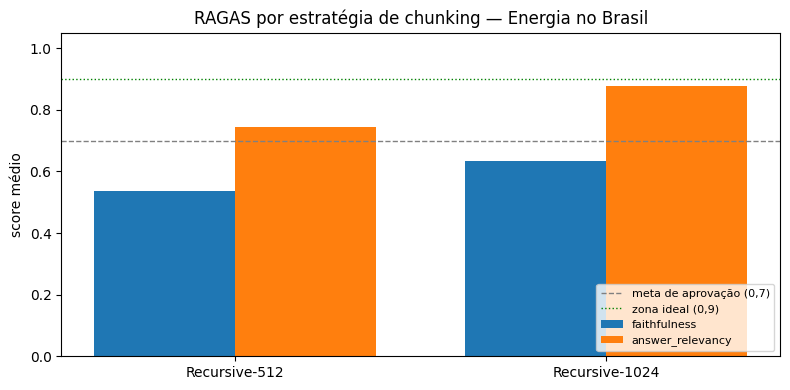

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
largura = 0.38
posicoes = range(len(resumo))
ax.bar([p - largura / 2 for p in posicoes], resumo["faithfulness_media"], largura, label="faithfulness")
ax.bar([p + largura / 2 for p in posicoes], resumo["answer_relevancy_media"], largura, label="answer_relevancy")
ax.axhline(0.7, linestyle="--", linewidth=1, color="gray", label="meta de aprovação (0,7)")
ax.axhline(0.9, linestyle=":", linewidth=1, color="green", label="zona ideal (0,9)")
ax.set_xticks(list(posicoes), resumo["config"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score médio")
ax.set_title(f"RAGAS por estratégia de chunking — {DOMINIO}")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# Critério de escolha: maior faithfulness médio (fidelidade aos documentos é a prioridade de um RAG);
# em caso de empate (diferença < 0,02), vence o maior answer_relevancy.
ordenado = resumo.sort_values(["faithfulness_media", "answer_relevancy_media"], ascending=False).reset_index(drop=True)
lider, vice = ordenado.iloc[0], ordenado.iloc[1]
if lider["faithfulness_media"] - vice["faithfulness_media"] < 0.02 and vice["answer_relevancy_media"] > lider["answer_relevancy_media"]:
    lider, vice = vice, lider
MELHOR_CHUNK = int(lider["chunk_size"])

print(f"🏆 Configuração vencedora: Recursive-{MELHOR_CHUNK}")
print(f"   faithfulness médio {lider['faithfulness_media']:.3f} (vs. {vice['faithfulness_media']:.3f} da {vice['config']})")
print(f"   answer_relevancy médio {lider['answer_relevancy_media']:.3f} (vs. {vice['answer_relevancy_media']:.3f})")
print(f"   Meta de aprovação (≥0,7): {'✅ atingida' if lider['faithfulness_media'] >= 0.7 else '❌ NÃO atingida — iterar no prompt/k/chunking'}")

🏆 Configuração vencedora: Recursive-1024
   faithfulness médio 0.635 (vs. 0.535 da Recursive-512)
   answer_relevancy médio 0.878 (vs. 0.745)
   Meta de aprovação (≥0,7): ❌ NÃO atingida — iterar no prompt/k/chunking


### 📝 Conclusão da comparação (gerada a partir dos números)

In [26]:
def montar_conclusao() -> str:
    """Escreve a justificativa da escolha com base nos scores medidos."""
    linhas_cfg = "\n".join(
        f"| {r.config} | {r.faithfulness_media:.3f} | {r.answer_relevancy_media:.3f} | {r.recuperacao_fonte:.0%} |"
        for r in resumo.itertuples())
    menor = resumo.sort_values("chunk_size").iloc[0]
    maior = resumo.sort_values("chunk_size").iloc[-1]
    piv = tabela_ragas.pivot_table(index="user_input", columns="chunk_size", values="faithfulness")
    amplitude = (piv.max(axis=1) - piv.min(axis=1)).sort_values(ascending=False)
    pergunta_sensivel = amplitude.index[0]
    valores_sensivel = ", ".join(f"{cs}: {piv.loc[pergunta_sensivel, cs]:.2f}" for cs in piv.columns)
    rec = {int(r.chunk_size): r.recuperacao_fonte for r in resumo.itertuples()}
    if MELHOR_CHUNK == int(menor["chunk_size"]):
        explicacao = (f"**Por quê.** Na nossa base as respostas são pontuais (limites em kW, prazos, percentuais), e chunks "
                      f"de {MELHOR_CHUNK} caracteres geram embeddings mais específicos: o retriever trouxe o documento certo em "
                      f"{rec[MELHOR_CHUNK]:.0%} das perguntas, e o contexto enviado ao LLM tem menos texto irrelevante para ele "
                      f"misturar na resposta. Com {int(maior['chunk_size'])} caracteres, cada trecho junta tabelas, notas e "
                      f"parágrafos vizinhos e o embedding fica genérico (recuperação: {rec[int(maior['chunk_size'])]:.0%}).")
    elif MELHOR_CHUNK == int(maior["chunk_size"]):
        explicacao = (f"**Por quê.** Nos nossos documentos a informação costuma vir com condições e exceções no mesmo parágrafo "
                      f"(ex.: limites de minigeração por tipo de fonte). Chunks de {MELHOR_CHUNK} caracteres mantêm a regra "
                      f"inteira num só trecho (recuperação da fonte certa: {rec[MELHOR_CHUNK]:.0%}). Com "
                      f"{int(menor['chunk_size'])} caracteres a regra é cortada e o modelo recebe só metade "
                      f"(recuperação: {rec[int(menor['chunk_size'])]:.0%}), o que o leva a completar o resto.")
    else:
        explicacao = (f"**Por quê.** É o equilíbrio do trade-off visto na Aula 07. Com {int(menor['chunk_size'])} caracteres, "
                      f"regras e números ficam cortados entre trechos (recuperação da fonte certa: "
                      f"{rec[int(menor['chunk_size'])]:.0%}). Com {int(maior['chunk_size'])}, cada trecho mistura mais assuntos e "
                      f"o embedding fica menos específico (recuperação: {rec[int(maior['chunk_size'])]:.0%}). Com {MELHOR_CHUNK}, "
                      f"o trecho costuma conter a regra completa sem diluir o significado (recuperação: {rec[MELHOR_CHUNK]:.0%}).")
    return f"""
| configuração | faithfulness médio | answer_relevancy médio | fonte certa recuperada |
|---|---|---|---|
{linhas_cfg}

**Vencedora: Recursive-{MELHOR_CHUNK}.** Teve o maior faithfulness médio ({lider['faithfulness_media']:.3f}), critério
prioritário porque mede se a resposta está ancorada nos documentos, e answer_relevancy de {lider['answer_relevancy_media']:.3f}.
{'Ficou acima da meta de aprovação (0,7)' if lider['faithfulness_media'] >= 0.7 else 'Ficou ABAIXO da meta de 0,7'}
{'e dentro da zona ideal (≥ 0,9).' if lider['faithfulness_media'] >= 0.9 else 'e abaixo da zona ideal de 0,9.'}

{explicacao}
A pergunta mais sensível ao tamanho do chunk foi *"{pergunta_sensivel}"* (faithfulness por chunk_size → {valores_sensivel}).
"""

display(Markdown(montar_conclusao()))


| configuração | faithfulness médio | answer_relevancy médio | fonte certa recuperada |
|---|---|---|---|
| Recursive-512 | 0.535 | 0.745 | 100% |
| Recursive-1024 | 0.635 | 0.878 | 100% |

**Vencedora: Recursive-1024.** Teve o maior faithfulness médio (0.635), critério
prioritário porque mede se a resposta está ancorada nos documentos, e answer_relevancy de 0.878.
Ficou ABAIXO da meta de 0,7
e abaixo da zona ideal de 0,9.

**Por quê.** Nos nossos documentos a informação costuma vir com condições e exceções no mesmo parágrafo (ex.: limites de minigeração por tipo de fonte). Chunks de 1024 caracteres mantêm a regra inteira num só trecho (recuperação da fonte certa: 100%). Com 512 caracteres a regra é cortada e o modelo recebe só metade (recuperação: 100%), o que o leva a completar o resto.
A pergunta mais sensível ao tamanho do chunk foi *"Qual capacidade instalada de micro e minigeração distribuída o PDE 2034 projeta para 2034 no cenário de referência?"* (faithfulness por chunk_size → 512: 1.00, 1024: 0.33).


In [27]:
# Experimento extra (diferencial): o reranking melhora a configuração vencedora?
RODAR_EXPERIMENTO_RERANK = True

if RODAR_EXPERIMENTO_RERANK:
    df_rerank = avaliar(gerar_registros(PERGUNTAS_AVALIACAO, colecoes[MELHOR_CHUNK], rerank=True))
    sem = tabela_ragas[tabela_ragas["chunk_size"] == MELHOR_CHUNK]
    comparacao_rerank = pd.DataFrame({
        "versão": [f"Recursive-{MELHOR_CHUNK} sem reranking", f"Recursive-{MELHOR_CHUNK} + cross-encoder"],
        "faithfulness_media": [sem["faithfulness"].mean(), df_rerank["faithfulness"].mean()],
        "answer_relevancy_media": [sem["answer_relevancy"].mean(), df_rerank["answer_relevancy"].mean()],
        "fonte_certa_recuperada": [sem["recuperou_fonte_esperada"].mean(), df_rerank["recuperou_fonte_esperada"].mean()],
    }).round(3)
    display(comparacao_rerank)
    ganho = comparacao_rerank["faithfulness_media"].iloc[1] - comparacao_rerank["faithfulness_media"].iloc[0]
    print(f"Efeito do reranking no faithfulness: {ganho:+.3f}")

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,versão,faithfulness_media,answer_relevancy_media,fonte_certa_recuperada
0,Recursive-1024 sem reranking,0.635,0.878,1.000
1,Recursive-1024 + cross-encoder,0.792,0.789,0.875


Efeito do reranking no faithfulness: +0.157


### 📋 Bloco de resultados para o README

A célula abaixo imprime as tabelas de resultados **já preenchidas com os números desta execução**.
Copie a saída e cole no `README.md` entre as marcas `<!-- RESULTADOS:INICIO -->` e `<!-- RESULTADOS:FIM -->`,
para que o README nunca fique desatualizado em relação ao notebook.


In [28]:
def bloco_readme() -> str:
    """Gera as tabelas de resultados em Markdown, prontas para colar no README."""
    linhas = ["**Chunking:**", "",
              "| Config | `chunk_size` | `chunk_overlap` | Nº de chunks | Tamanho médio | Indexada? |",
              "|---|---|---|---|---|---|"]
    for e in estatisticas:
        linhas.append(f"| {e['config']} | {e['config'].split('-')[1]} | {e['chunk_overlap']} | "
                      f"{e['nº de chunks']:,} | {e['tamanho médio']} | {e['indexada e avaliada']} |".replace(",", " "))

    linhas += ["", f"**RAGAS — {len(PERGUNTAS)} perguntas, sem reranking (só o `chunk_size` muda):**", "",
               "| Config | faithfulness médio | answer_relevancy médio | Fonte certa recuperada |",
               "|---|---|---|---|"]
    for r in resumo.itertuples():
        marca = " 🏆" if int(r.chunk_size) == MELHOR_CHUNK else ""
        linhas.append(f"| {r.config}{marca} | {r.faithfulness_media:.3f} | "
                      f"{r.answer_relevancy_media:.3f} | {r.recuperacao_fonte:.0%} |")

    if "comparacao_rerank" in globals():
        linhas += ["", "**Efeito do reranking (diferencial), sobre a configuração vencedora:**", "",
                   "| Versão | faithfulness | answer_relevancy | Fonte certa recuperada |", "|---|---|---|---|"]
        for r in comparacao_rerank.itertuples():
            linhas.append(f"| {r.versão} | {r.faithfulness_media:.3f} | "
                          f"{r.answer_relevancy_media:.3f} | {r.fonte_certa_recuperada:.1%} |")

    media = float(resumo.loc[resumo["chunk_size"] == MELHOR_CHUNK, "faithfulness_media"].iloc[0])
    caracteres = f"{sum(len(p.page_content) for p in paginas):,}".replace(",", " ")
    linhas += ["", f"**Vencedora: Recursive-{MELHOR_CHUNK}** · faithfulness médio {media:.3f} "
                   f"({'acima' if media >= 0.7 else 'ABAIXO'} da meta de 0,7) · "
                   f"base de {len(paginas)} páginas e {caracteres} caracteres"]
    return "\n".join(linhas)


print(bloco_readme())


**Chunking:**

| Config | `chunk_size` | `chunk_overlap` | Nº de chunks | Tamanho médio | Indexada? |
|---|---|---|---|---|---|
| Recursive-256 | 256 | 32 | 9 583 | 191 | não (ver nota) |
| Recursive-512 | 512 | 64 | 4 836 | 384 | sim |
| Recursive-1024 | 1024 | 128 | 2 792 | 690 | sim |

**RAGAS — 8 perguntas, sem reranking (só o `chunk_size` muda):**

| Config | faithfulness médio | answer_relevancy médio | Fonte certa recuperada |
|---|---|---|---|
| Recursive-512 | 0.535 | 0.745 | 100% |
| Recursive-1024 🏆 | 0.635 | 0.878 | 100% |

**Efeito do reranking (diferencial), sobre a configuração vencedora:**

| Versão | faithfulness | answer_relevancy | Fonte certa recuperada |
|---|---|---|---|
| Recursive-1024 sem reranking | 0.635 | 0.878 | 100.0% |
| Recursive-1024 + cross-encoder | 0.792 | 0.789 | 87.5% |

**Vencedora: Recursive-1024** · faithfulness médio 0.635 (ABAIXO da meta de 0,7) · base de 839 páginas e 1 825 861 caracteres


## 9. Análise crítica — onde o pipeline falhou

Pegamos a pergunta com **menor faithfulness** na configuração vencedora e olhamos os trechos que o retriever entregou ao LLM.

In [29]:
vencedora = tabela_ragas[tabela_ragas["chunk_size"] == MELHOR_CHUNK].copy()
vencedora["soma"] = vencedora["faithfulness"].fillna(0) + vencedora["answer_relevancy"].fillna(0)
pior = vencedora.sort_values(["faithfulness", "soma"]).iloc[0]

display(Markdown(
    f"**❓ Pergunta:** {pior['user_input']}\n\n"
    f"**faithfulness:** {pior['faithfulness']:.3f} · **answer_relevancy:** {pior['answer_relevancy']:.3f} · "
    f"**documento esperado:** `{pior['fonte_esperada']}` · **recuperado?** {'sim' if pior['recuperou_fonte_esperada'] else 'não'}\n\n"
    f"**Resposta gerada:**\n\n{pior['response']}\n\n**Fontes recuperadas:**\n{pior['fontes']}"
))
for i, contexto in enumerate(pior["retrieved_contexts"], 1):
    display(Markdown(f"**Trecho {i}:**\n```\n{contexto[:700]}\n```"))

**❓ Pergunta:** Qual é a potência máxima de uma central de microgeração distribuída?

**faithfulness:** 0.333 · **answer_relevancy:** 0.787 · **documento esperado:** `ren_aneel_1059_2023.pdf` · **recuperado?** sim

**Resposta gerada:**

A potência instalada em corrente alternada de uma central de microgeração distribuída deve ser menor ou igual a 75 kW (Fonte: Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 3).

**Fontes recuperadas:**
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 6 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Plano Decenal de Expansão de Energia 2034 (MME/EPE), p. 380 — https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/plano-decenal-de-expansao-de-energia-2034
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 3 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 15 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 16 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 20 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf

**Trecho 1:**
```
§ 1º Caso a conexão nova ou o aumento de potência injetada de microgeração ou minigeração
distribuída implique inversão do fluxo de potência no posto de transformação da distribuidora ou no
```

**Trecho 2:**
```
uso principal para baterias em unidades consumidoras no horizonte decenal, que serão
discutidas em mais detalhes na sequência:
▪ Aumento do autoconsumo da microgeração distribuída;
```

**Trecho 3:**
```
XXIX-A - microgeração distribuída: central geradora de energia elétrica que utilize fontes
renováveis ou, conforme Resolução Normativa nº 1.031, de 26 de julho de 2022, de cogeração qualificada,
conectada à rede de distribuição de energia elétrica por meio de unidade consumidora, da qual é
considerada parte, que possua potência instalada em corrente alternada menor ou igual a 75 kW;”

XXIX-B - minigeração distribuída: central geradora de energia elétrica que utilize fontes
renováveis ou, conforme Resolução Normativa nº 1.031, de 26 de julho de 2022, de cogeração qualificada,
conectada à rede de distribuição de energia elétrica por meio de unidade consumidora, da qual é
considerada parte, que
```

**Trecho 4:**
```
Seção I
Da conexão de microgeração e minigeração distribuída

Art. 655-A. A distribuidora deve atender à solicitação de conexão ou de aumento de potência
disponibilizada de unidade consumidora com microgeração ou minigeração distribuída, com ou sem
sistema de armazenamento de energia, de acordo com os procedimentos, prazos e condições
estabelecidos no Capítulo II do Título I e do Módulo 3 do PRODIST.
```

**Trecho 5:**
```
Parágrafo único. A distribuidora deve realizar a vistoria e instalar ou adequar o sistema de
medição conforme procedimentos e prazos estabelecidos na Seção XIV do Capítulo II do Título I.

Art. 655-B. Para fins de enquadramento de microgeração ou minigeração distribuída como
central geradora de fonte despachável, o cálculo da produção média mensal da microgeração ou
minigeração distribuída é obtido pela seguinte equação:

𝐸𝑔= 𝑃𝑔 × 𝐹𝐶 × 24 ℎ𝑜𝑟𝑎𝑠 × 30 𝑑𝑖𝑎𝑠

em que:

𝐸𝑔 é a produção média mensal da microgeração ou minigeração distribuída;

𝑃𝑔 é a potência instalada da microgeração ou minigeração distribuída;

𝐹𝐶 é o fator de capacidade para a fonte solar, estabelecido em 16%.

Art. 655-C. O con
```

**Trecho 6:**
```
IV - tido sua energia elétrica comprometida diretamente com uma distribuidora.

§ 5º É vedado o enquadramento no SCEE de unidade consumidora com microgeração ou
minigeração distribuída que não se caracterize como produção de energia elétrica para consumo próprio.

§ 6º Caso a distribuidora identifique situações de enquadramento indevido no SCEE, deve
aplicar o estabelecido no art. 655-F.

§ 7º No caso de constatação de alteração à revelia das características originais da central
geradora que influencie nas condições de participação no SCEE, deve-se observar o art. 655-F.

Art. 655-E. É vedada a divisão de central geradora em unidades de menor porte para se
enquadrar nos limites de potência i
```

In [30]:
# Diagnóstico: a falha foi na RECUPERAÇÃO (fonte certa não veio) ou na GERAÇÃO (veio, mas o modelo extrapolou)?
if pior["faithfulness"] >= 0.9 and pior["recuperou_fonte_esperada"]:
    diagnostico = (
        f"**Sem alucinação relevante.** Mesmo a pergunta com menor score teve faithfulness de {pior['faithfulness']:.2f} e o "
        f"documento certo (`{pior['fonte_esperada']}`) foi recuperado. O ponto mais fraco foi o answer_relevancy "
        f"({pior['answer_relevancy']:.2f}): a resposta trouxe contexto além do perguntado ou citou condições que a "
        "pergunta não pedia, o que reduz o foco medido pela métrica."
    )
    melhoria = (
        "**Melhorias propostas:** (1) pedir no prompt uma primeira frase com a resposta direta e só depois os detalhes; "
        "(2) reranking para que o trecho mais específico venha primeiro; (3) testar `K_FINAL` menor (3) para reduzir "
        "contexto lateral."
    )
elif not pior["recuperou_fonte_esperada"]:
    diagnostico = (
        f"**Falha de recuperação.** O trecho com a resposta está em `{pior['fonte_esperada']}`, mas nenhum dos {K_FINAL} "
        "trechos enviados ao LLM veio desse documento. Os documentos recuperados tratam de assuntos vizinhos e usam "
        "vocabulário parecido com o da pergunta, então a similaridade vetorial os colocou na frente. Sem o trecho certo, "
        "o modelo respondeu com o que tinha (ou disse que não encontrou), e o faithfulness caiu."
    )
    melhoria = (
        "**Melhorias propostas:** (1) reranking com cross-encoder sobre 12 candidatos, que lê pergunta e trecho juntos "
        "(efeito medido no experimento acima); (2) filtro de metadados por categoria quando a pergunta é de um tema conhecido; "
        "(3) aumentar `K_FINAL` de 4 para 6."
    )
else:
    diagnostico = (
        f"**Falha de geração.** O documento certo (`{pior['fonte_esperada']}`) estava entre os trechos recuperados, mas a "
        "resposta incluiu afirmações que o juiz não encontrou no contexto: o modelo completou ou reformulou números e "
        "condições além do que o trecho dizia, ou o trecho recuperado trazia só parte da informação."
    )
    melhoria = (
        "**Melhorias propostas:** (1) reforçar no prompt que números e condições devem ser copiados do trecho, sem "
        "complementar; (2) usar chunks maiores ou Parent-Document Retriever para o trecho trazer a informação completa; "
        "(3) reranking para colocar o trecho mais específico em primeiro."
    )
display(Markdown(diagnostico + "\n\n" + melhoria))

**Falha de geração.** O documento certo (`ren_aneel_1059_2023.pdf`) estava entre os trechos recuperados, mas a resposta incluiu afirmações que o juiz não encontrou no contexto: o modelo completou ou reformulou números e condições além do que o trecho dizia, ou o trecho recuperado trazia só parte da informação.

**Melhorias propostas:** (1) reforçar no prompt que números e condições devem ser copiados do trecho, sem complementar; (2) usar chunks maiores ou Parent-Document Retriever para o trecho trazer a informação completa; (3) reranking para colocar o trecho mais específico em primeiro.

## 10. Pipeline final — pronto para virar `@tool` no CKP03

A coleção vencedora passa a ser a padrão. No CKP03 basta envolver `buscar()` com o decorador `@tool` do LangChain.

In [31]:
COLECAO_ATIVA = colecoes[MELHOR_CHUNK]
print(f"Coleção ativa: {COLECAO_ATIVA.name} ({COLECAO_ATIVA.count()} chunks) · reranking ligado por padrão")

# Exemplo de uso como ferramenta: uma chamada, resposta com fontes
r = responder(PERGUNTAS[0])
display(Markdown(f"**❓ {r['pergunta']}**\n\n{r['resposta']}\n\n**📚 Fontes:**\n{formatar_fontes(r['trechos'])}"))

Coleção ativa: energia_no_brasil_cs1024 (2792 chunks) · reranking ligado por padrão


**❓ Qual é a potência máxima de uma central de microgeração distribuída?**

A potência instalada em corrente alternada de uma central de microgeração distribuída deve ser menor ou igual a 75 kW (Fonte: Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 3).

**📚 Fontes:**
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 15 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 3 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 6 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 35 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 20 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf
- Resolução Normativa ANEEL nº 1.059/2023 — regulamenta a Lei 14.300/2022 (micro e minigeração distribuída), p. 10 — http://www2.aneel.gov.br/cedoc/ren20231059.pdf

## 11. Interface Gradio (diferencial)

Chat com o RAG integrado: filtro por categoria (*metadata filtering*), liga/desliga do reranking e fontes citadas em cada
resposta. `share=True` publica uma URL pública temporária (válida por 72 h) para o professor testar sem rodar o notebook.

> A célula abaixo ocupa a sessão enquanto o servidor está no ar — é a última do notebook por isso.


In [32]:
import gradio as gr

# Encerra qualquer instância anterior do Gradio aberta nesta sessão do Colab (libera a porta).
try:
    gr.close_all()
except Exception:
    pass


In [33]:
CATEGORIAS = ["Todas"] + sorted(set(manifesto["categoria"].replace("", "nao_informado")))


def conversar(mensagem: str, historico: list, categoria: str, usar_rerank: bool) -> str:
    """Função do chat: aplica o filtro escolhido, roda o RAG e anexa as fontes."""
    filtro = None if categoria == "Todas" else {"categoria": categoria}
    r = responder(mensagem, filtro=filtro, rerank=usar_rerank)
    fontes = formatar_fontes(r["trechos"]) or "—"
    return f"{r['resposta']}\n\n---\n**📚 Fontes consultadas**\n{fontes}"


app = gr.ChatInterface(
    fn=conversar,
    title=f"🧠 DocMind — {DOMINIO}",
    description="Pergunte sobre os documentos da base. Cada resposta traz o documento e a página de origem.",
    additional_inputs=[
        gr.Dropdown(CATEGORIAS, value="Todas", label="Filtrar por categoria"),
        gr.Checkbox(value=True, label="Reranking com cross-encoder"),
    ],
    examples=[[p, "Todas", True] for p in PERGUNTAS[:3]],
)

# share=True gera a URL pública temporária. Sem nest_asyncio e sem porta fixa: o próprio Gradio
# escolhe uma porta livre, e o loop de eventos do Colab é usado como está.
app.launch(share=True)


/usr/local/lib/python3.13/dist-packages/uvicorn/server.py:86: RuntimeWarning: coroutine 'Server.serve' was never awaited
  return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
Exception in thread Thread-9 (run):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/server.py", line 86, in run
    return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
TypeError: _patch_asyncio.<locals>.run() got an unexpected keyword argument 'loop_factory'
Exception in thread Thread-10 (run):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/

KeyboardInterrupt: 

## 12. Como adicionar novos documentos à base

**Opção A — reconstruir tudo (recomendado antes da entrega):**
1. Coloque o arquivo (PDF com texto, TXT ou MD) em `docs/`.
2. Adicione uma linha no `fontes.csv` com `arquivo, titulo, tipo, categoria, data, url_fonte`.
3. Rode o notebook do início (*Run All*). A base é reindexada e o RAGAS recalculado.

**Opção B — incremental, sem reindexar o resto:** use a função abaixo (ela copia o arquivo, atualiza o `fontes.csv` e indexa
só os chunks novos em todas as coleções).

In [34]:
def adicionar_documento(caminho: str, titulo: str, tipo: str, categoria: str, data: str, url_fonte: str) -> None:
    """Adiciona um documento novo à base: copia para docs/, registra no fontes.csv e indexa nas coleções."""
    global manifesto
    origem = Path(caminho)
    if origem.suffix.lower() not in EXTENSOES_ACEITAS:
        raise ValueError(f"Formato não suportado: {origem.suffix}. Use PDF, TXT ou MD.")
    if origem.name in set(manifesto["arquivo"]):
        raise ValueError(f"{origem.name} já está na base.")
    if not url_fonte:
        raise ValueError("Informe url_fonte: o CKP02 exige a fonte de cada documento.")
    if origem.resolve() != (PASTA_DOCS / origem.name).resolve():
        shutil.copy(origem, PASTA_DOCS / origem.name)

    nova_linha = pd.DataFrame([{"arquivo": origem.name, "titulo": titulo, "tipo": tipo,
                                "categoria": categoria, "data": data, "url_fonte": url_fonte}])
    manifesto = pd.concat([manifesto, nova_linha], ignore_index=True)
    manifesto.to_csv(ARQ_FONTES, index=False)

    paginas_novas = carregar_documento(next(nova_linha.itertuples()))
    for cs, colecao in colecoes.items():
        adicionar_chunks(colecao, gerar_chunks(paginas_novas, cs))
    print(f"✅ {titulo}: {len(paginas_novas)} páginas indexadas em {len(colecoes)} coleções.")


# Exemplo (descomente e ajuste):
# adicionar_documento("/content/novo_documento.pdf", "Título oficial", "manual", "categoria", "2025-01-01", "https://...")

---
### ✅ Checklist de entrega

- [x] 6 documentos reais e oficiais em `docs/` + `fontes.csv` com link de origem de cada um
- [x] Pipeline completo `load → split → embed → store → retrieve → generate`, com a resposta citando documento e página
- [x] `RecursiveCharacterTextSplitter` com os separadores da Aula 06 e overlap de 12,5%
- [x] 2 configurações de `chunk_size` (512 e 1024) indexadas, comparadas e medidas com RAGAS
- [x] 8 perguntas de avaliação (mínimo 5) com resposta conferida nos PDFs, tabela por pergunta e por configuração
- [x] Escolha da configuração vencedora justificada pelos números, com análise da pior pergunta
- [x] Diferenciais: metadata filtering (`where=`), reranking com cross-encoder (efeito medido) e interface Gradio
- [x] *Runtime → Run all* sem erros (Gradio Interface não roda por nada)
- [x] Export `.ipynb` executado + link do Colab com permissão de leitura + `README.md` com integrantes e RMs
